# Experiment 12
# Generate Square Pattern with Star in Parallel on GPU Using CUDA

## Aim
To generate a square star pattern using CUDA threads executing in parallel on GPU.

## Theory
Each GPU thread maps to one matrix location. Threads execute in parallel and fill a square matrix which is later displayed as a star pattern.

In [1]:
!nvidia-smi

Mon Jun  1 10:07:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from numba import cuda
import numpy as np
import matplotlib.pyplot as plt
import time

## Create Input Matrix

In [3]:
n=10
pattern=np.zeros((n,n),dtype=np.int32)
pattern

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int32)

## CUDA Kernel

In [4]:
@cuda.jit
def star_pattern_kernel(arr):
    row,col=cuda.grid(2)
    if row < arr.shape[0] and col < arr.shape[1]:
        arr[row,col]=1

## Transfer Data To GPU

In [5]:
d_pattern=cuda.to_device(pattern)

## Thread and Block Configuration

In [6]:
threads=(16,16)
blocks=((n+15)//16,(n+15)//16)
print('Threads:',threads)
print('Blocks:',blocks)

Threads: (16, 16)
Blocks: (1, 1)


## Launch Kernel

In [7]:
start=time.time()
star_pattern_kernel[blocks,threads](d_pattern)
cuda.synchronize()
gpu_time=time.time()-start
print('GPU Execution Time:',gpu_time)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


GPU Execution Time: 4.516650676727295


## Copy Result Back To CPU

In [8]:
result=d_pattern.copy_to_host()
result

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int32)

## Display Matrix

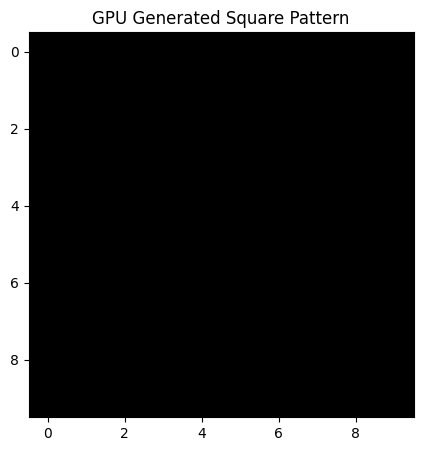

In [9]:
plt.figure(figsize=(5,5))
plt.imshow(result,cmap='gray')
plt.title('GPU Generated Square Pattern')
plt.show()

## Print Star Pattern

In [10]:
for row in result:
    for col in row:
        if col==1:
            print('*',end=' ')
    print()

* * * * * * * * * * 
* * * * * * * * * * 
* * * * * * * * * * 
* * * * * * * * * * 
* * * * * * * * * * 
* * * * * * * * * * 
* * * * * * * * * * 
* * * * * * * * * * 
* * * * * * * * * * 
* * * * * * * * * * 


## Observation
All matrix elements were filled in parallel by CUDA threads.

## Result
Square star pattern was generated successfully using CUDA GPU parallel execution.